Вычисления будут производиться на: cpu
Работаем со столбцом: 'text'

Распределение чистых и уверенных классов:
category
stock_market            302
technology              133
finance_banking         111
corporate_earnings       99
government_policy        35
mergers_acquisitions      7
Name: count, dtype: int64

Оптимальная входная размерность (признаков): 3500
Количество классов: 6 -> ['corporate_earnings' 'finance_banking' 'government_policy'
 'mergers_acquisitions' 'stock_market' 'technology']

--- Старт обучения модели: Wide & Deep (ELU) ---
Эпоха [1/12] | Train Loss: 0.937 | Val Loss: 1.546 | Val Acc: 86.96%
Эпоха [2/12] | Train Loss: 0.424 | Val Loss: 1.179 | Val Acc: 92.75%
Эпоха [3/12] | Train Loss: 0.329 | Val Loss: 0.753 | Val Acc: 92.03%
Эпоха [4/12] | Train Loss: 0.292 | Val Loss: 0.500 | Val Acc: 93.48%
Эпоха [5/12] | Train Loss: 0.279 | Val Loss: 0.451 | Val Acc: 92.03%
Эпоха [6/12] | Train Loss: 0.278 | Val Loss: 0.464 | Val Acc: 92.03%
Эпоха [7/12] | Train Loss: 0.266 

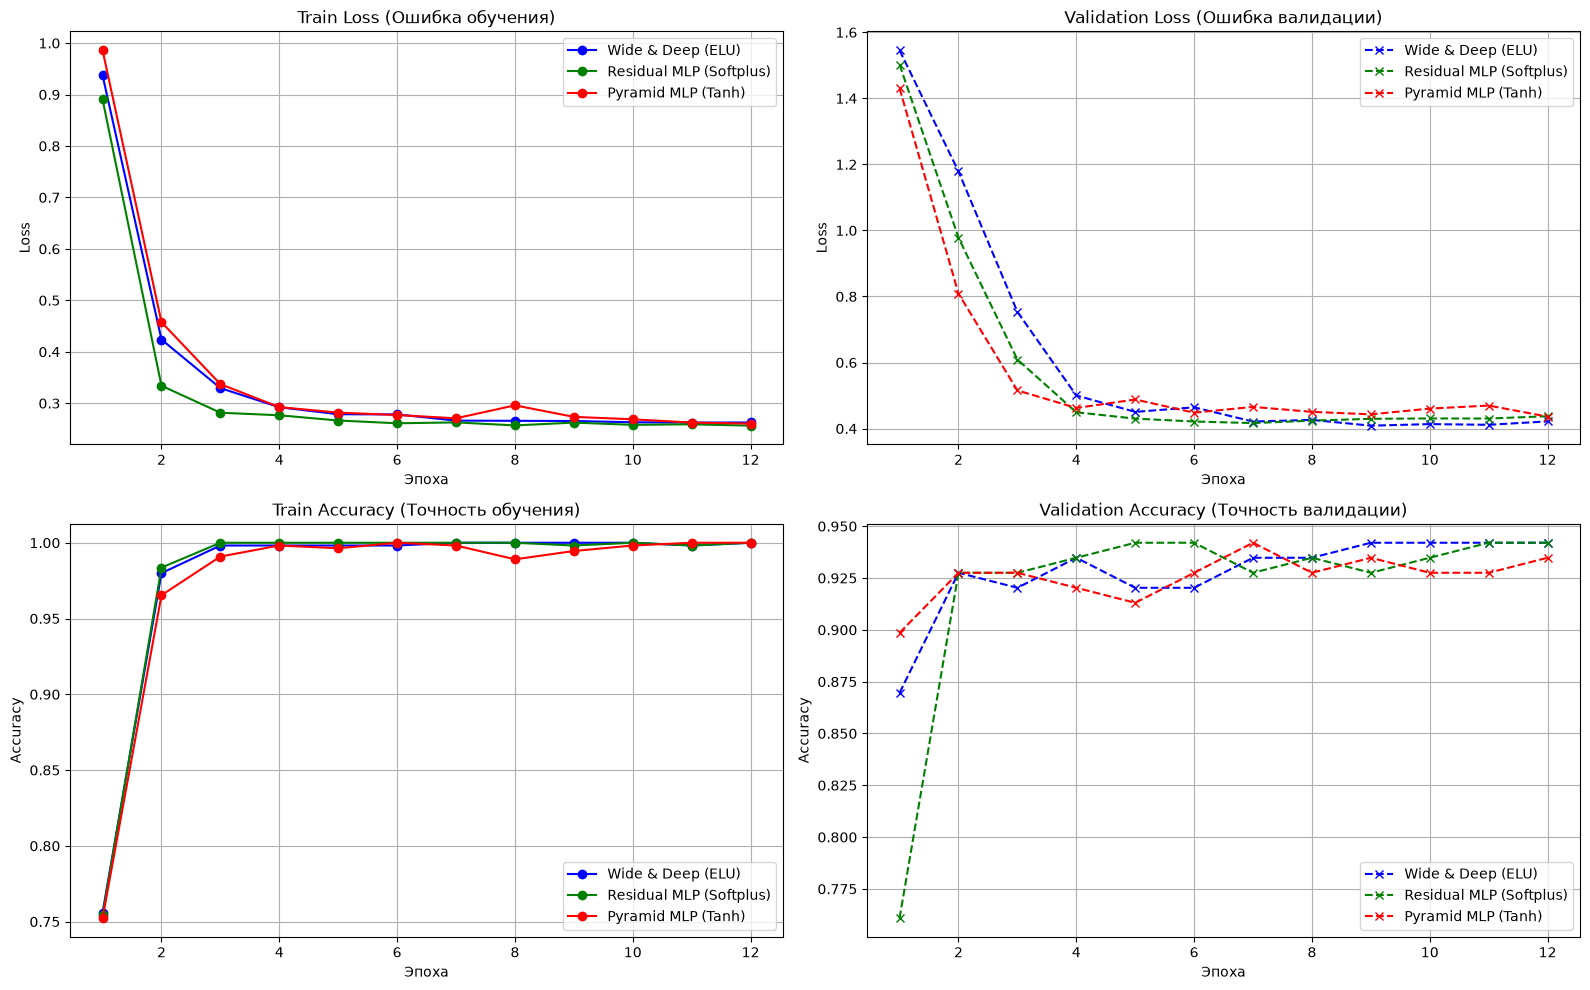


--- Итоговые результаты на валидации ---
Модель 'Wide & Deep (ELU)': Лучшая Val Accuracy = 94.20%
Модель 'Residual MLP (Softplus)': Лучшая Val Accuracy = 94.20%
Модель 'Pyramid MLP (Tanh)': Лучшая Val Accuracy = 94.20%


In [5]:
import os
import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Настройка GPU устройства
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Вычисления будут производиться на: {device}")

# Фиксируем сиды для воспроизводимости результатов
torch.manual_seed(42)
np.random.seed(42)

# ==========================================
# 1. ЧТЕНИЕ ДАТАСЕТА
# ==========================================

path = os.path.abspath(os.path.join(os.getcwd(), '..'))
csv_file = os.path.join(path, 'data', 'processed', 'business_data_cleaned.csv')
if not os.path.exists(csv_file):
    raise FileNotFoundError(f"Файл '{csv_file}' не найден!")

df = pd.read_csv(csv_file)

if 'text' in df.columns:
    text_col = 'text'
elif 'content' in df.columns:
    text_col = 'content'
else:
    text_cols = [col for col in df.columns if df[col].dtype == 'object']
    text_col = max(text_cols, key=lambda col: df[col].astype(str).str.len().mean())

print(f"Работаем со столбцом: '{text_col}'")
df = df[[text_col]].rename(columns={text_col: 'content'})

# ==========================================
# 2. СТРОГАЯ ОЧИСТКА И ФИЛЬТРАЦИЯ ШУМА
# ==========================================
df['content'] = df['content'].fillna('').astype(str)

def clean_text(text):
    text = re.sub(r"you have exhausted your monthly limit.*?sign in", "", text, flags=re.IGNORECASE)
    text = re.sub(r"register to read more.*?sign in", "", text, flags=re.IGNORECASE)
    text = re.sub(r"\badvertisement\b", "", text, flags=re.IGNORECASE)
    text = re.sub(r"http\S+|pictwittercom\S+", "", text, flags=re.IGNORECASE)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip().lower()
    return text

df['content'] = df['content'].apply(clean_text)
df = df[df['content'].str.split().apply(len) > 40] # Отсекаем слишком короткие
df = df.drop_duplicates(subset=['content']).reset_index(drop=True)

# Ключевые слова
keywords = {
    "finance_banking": ["bank", "loan", "credit", "interest", "reserve", "monetary", "federal reserve", "deposit"],
    "stock_market": ["stock", "share", "market", "trading", "nifty", "sensex", "index", "investor", "portfolio"],
    "corporate_earnings": ["profit", "earning", "revenue", "quarter", "net profit", "growth", "sales", "income"],
    "technology": ["tech", "software", "digital", "innovation", "ai", "artificial intelligence", "startup", "app"],
    "government_policy": ["government", "policy", "budget", "minister", "parliament", "tax", "regulation", "finance ministry"],
    "mergers_acquisitions": ["merger", "acquisition", "deal", "buyout", "takeover", "stake", "acquire"],
}

# Функция СТРОГОЙ разметки (убираем класс 'other', берем только явных лидеров)
def classify_strict(text):
    scores = {cat: sum(1 for word in words if word in text) for cat, words in keywords.items()}
    
    # Сортируем категории по количеству совпадений (от большего к меньшему)
    sorted_scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    
    leader_cat, leader_score = sorted_scores[0]
    runner_up_cat, runner_up_score = sorted_scores[1]
    
    # Модель должна учиться ТОЛЬКО на чистых данных. 
    # Лидер должен иметь хотя бы 2 совпадения И опережать второе место минимум на 2 балла.
    if leader_score >= 2 and (leader_score - runner_up_score >= 2):
        return leader_cat
    return None # Спорные тексты отсекаем

df['category'] = df['content'].apply(classify_strict)
df = df.dropna(subset=['category']).reset_index(drop=True)

print("\nРаспределение чистых и уверенных классов:")
print(df['category'].value_counts())

# 3. КОДИРОВАНИЕ МЕТОК КЛАССОВ

label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(df['category'])
y_tensor = torch.tensor(encoded_labels, dtype=torch.long)

# ==========================================
# 4. НАСТРОЙКА TF-IDF С ОГРАНИЧЕНИЕМ СЛОВАРЯ
# ==========================================
vectorizer = TfidfVectorizer(
    stop_words='english',
    min_df=3,            # Игнорируем слишком редкие слова
    max_df=0.8,          # Игнорируем слишком частые слова
    max_features=3500,   # Ограничиваем емкость входа топ-3500 слов (спасет от переобучения)
    ngram_range=(1, 2)   # Захватываем пары слов (биграммы)
)
tfidf_matrix = vectorizer.fit_transform(df['content'])
num_samples, input_dim = tfidf_matrix.shape
num_classes = len(label_encoder.classes_)

print(f"\nОптимальная входная размерность (признаков): {input_dim}")
print(f"Количество классов: {num_classes} -> {label_encoder.classes_}")

# ==========================================
# 5. РАЗДЕЛЕНИЕ НА TRAIN / VAL
# ==========================================
indices = np.arange(num_samples)
train_idx, val_idx = train_test_split(indices, test_size=0.2, random_state=42, stratify=y_tensor)

X_train = torch.tensor(tfidf_matrix[train_idx].toarray(), dtype=torch.float32).to(device)
X_val = torch.tensor(tfidf_matrix[val_idx].toarray(), dtype=torch.float32).to(device)

y_train = y_tensor[train_idx].to(device)
y_val = y_tensor[val_idx].to(device)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=32, shuffle=False)

# ==========================================
# 6. СТАБИЛИЗИРОВАННЫЕ АРХИТЕКТУРЫ С МЯГКИМ DROPOUT (0.2)
# ==========================================

class WideELUModel(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ELU(),
            nn.Dropout(0.2), # Смягчили, чтобы не терять признаки
            nn.Linear(512, 64),
            nn.BatchNorm1d(64),
            nn.ELU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        return self.net(x)

class ResidualMLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.input_layer = nn.Linear(input_dim, 128)
        self.bn_input = nn.BatchNorm1d(128)
        self.activation = nn.ELU() # Заменили Softplus на более контрастный ELU для текстов
        self.dropout_input = nn.Dropout(0.2)
        
        self.res_block = nn.Sequential(
            nn.Linear(128, 128),
            nn.BatchNorm1d(128),
            nn.ELU(),
            nn.Dropout(0.2),
            nn.Linear(128, 128),
            nn.BatchNorm1d(128)
        )
        self.output_layer = nn.Linear(128, num_classes)
    def forward(self, x):
        x = self.dropout_input(self.activation(self.bn_input(self.input_layer(x))))
        x = x + self.res_block(x)
        x = self.activation(x)
        return self.output_layer(x)

class PyramidTanhModel(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.Tanh(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.Tanh(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.Tanh(),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        return self.net(x)

# 7. УНИВЕРСАЛЬНАЯ ФУНКЦИЯ ОБУЧЕНИЯ
# ==========================================
def train_and_evaluate(model_class, name, input_dim, num_classes, epochs=12):
    print(f"\n--- Старт обучения модели: {name} ---")
    
    model = model_class(input_dim=input_dim, num_classes=num_classes).to(device) 
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05) # Мягкое сглаживание меток
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)   
    
    # Планировщик плавно снижает шаг, помогая найти глобальный минимум
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=1, factor=0.5)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        running_loss, correct_train, total_train = 0.0, 0, 0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * batch_X.size(0)
            _, predicted = torch.max(outputs, 1)
            correct_train += (predicted == batch_y).sum().item()
            total_train += batch_y.size(0)

        # Валидация
        model.eval()
        val_loss_running, correct_val, total_val = 0.0, 0, 0
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                val_loss_running += loss.item() * batch_X.size(0)
                _, predicted = torch.max(outputs, 1)
                correct_val += (predicted == batch_y).sum().item()
                total_val += batch_y.size(0)

        current_val_loss = val_loss_running / total_val
        scheduler.step(current_val_loss)

        history['train_loss'].append(running_loss / total_train)
        history['val_loss'].append(current_val_loss)
        history['train_acc'].append(correct_train / total_train)
        history['val_acc'].append(correct_val / total_val)

        print(f"Эпоха [{epoch+1}/{epochs}] | Train Loss: {history['train_loss'][-1]:.3f} | Val Loss: {history['val_loss'][-1]:.3f} | Val Acc: {history['val_acc'][-1]*100:.2f}%")

    return history


# ==========================================
# 8. ЗАПУСК И СБОР РЕЗУЛЬТАТОВ
# ==========================================
epochs_count = 12
results = {
    'Wide & Deep (ELU)': train_and_evaluate(
        WideELUModel, 'Wide & Deep (ELU)', input_dim=input_dim, num_classes=num_classes, epochs=epochs_count
    ),
    'Residual MLP (Softplus)': train_and_evaluate(
        ResidualMLP, 'Residual MLP (Softplus)', input_dim=input_dim, num_classes=num_classes, epochs=epochs_count
    ),
    'Pyramid MLP (Tanh)': train_and_evaluate(
        PyramidTanhModel, 'Pyramid MLP (Tanh)', input_dim=input_dim, num_classes=num_classes, epochs=epochs_count
    )
}

# ==========================================
# 8. ГРАФИКИ
# ==========================================
epochs_range = range(1, epochs_count + 1)
plt.figure(figsize=(16, 10))
colors = {'Wide & Deep (ELU)': 'blue', 'Residual MLP (Softplus)': 'green', 'Pyramid MLP (Tanh)': 'red'}

plt.subplot(2, 2, 1)
for name, hist in results.items():
    plt.plot(epochs_range, hist['train_loss'], label=name, color=colors[name], marker='o')
plt.title('Train Loss (Ошибка обучения)')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
for name, hist in results.items():
    plt.plot(epochs_range, hist['val_loss'], label=name, color=colors[name], linestyle='--', marker='x')
plt.title('Validation Loss (Ошибка валидации)')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 3)
for name, hist in results.items():
    plt.plot(epochs_range, hist['train_acc'], label=name, color=colors[name], marker='o')
plt.title('Train Accuracy (Точность обучения)')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.subplot(2, 2, 4)
for name, hist in results.items():
    plt.plot(epochs_range, hist['val_acc'], label=name, color=colors[name], linestyle='--', marker='x')
plt.title('Validation Accuracy (Точность валидации)')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Итоговая таблица
print("\n--- Итоговые результаты на валидации ---")
for name, hist in results.items():
    best_val_acc = max(hist['val_acc'])
    print(f"Модель '{name}': Лучшая Val Accuracy = {best_val_acc*100:.2f}%")